<a href="https://colab.research.google.com/github/nsonyiwa-rose-nabakka/AI-STEM-shortcourse/blob/main/Week4_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 4: Exploring the Mathematics of your data

Using the NOAA Oceanic Nino Index dataset imported in week 3;

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/ahuang11/oni/master/oni.csv'
df = pd.read_csv(url)
df.head()

,season,year,sst_c,anom_c,threshold,cumulative,ntotal,oni
0,DJF,1950,25.01,-1.32,below,1,13,la_nina
1,JFM,1950,25.36,-1.20,below,2,13,la_nina
2,FMA,1950,25.88,-1.12,below,3,13,la_nina
3,MAM,1950,26.24,-1.08,below,4,13,la_nina
4,AMJ,1950,26.35,-1.10,below,5,13,la_nina


1. **Selected numerical variables**

*   sst_c - sea surface temperature (deg celcius)
*   anom_c - SST anomaly (deg celcius)
*   cumulative - how many consecutive seasons the current warm/cold spell has lasted







In [2]:
variables = ['sst_c', 'anom_c', 'cumulative']
data = df[variables].dropna()

stats = pd.DataFrame({

'mean': data.mean(),
'median': data.median(),
'range': data.max() - data.min(),
'variance': data.var(),
'std_dev': data.std()
})
stats.round(3)

,mean,median,range,variance,std_dev
sst_c,26.934,26.98,4.76,0.817,0.904
anom_c,0.019,-0.04,4.63,0.620,0.788
cumulative,7.893,5.00,51.00,62.603,7.912


2. Covariance and correlation: sst_c Vs anom_c

In [3]:
x = data['sst_c']
y = data['anom_c']

covariance = np.cov(x,y)[0,1]
correlation = x.corr(y)

print(f'Covariance: {covariance:.3f}')
print(f'Correlation: {correlation:.3f}')

Covariance: 0.623
Correlation: 0.874


3. Plot showing the relationship between the two variables

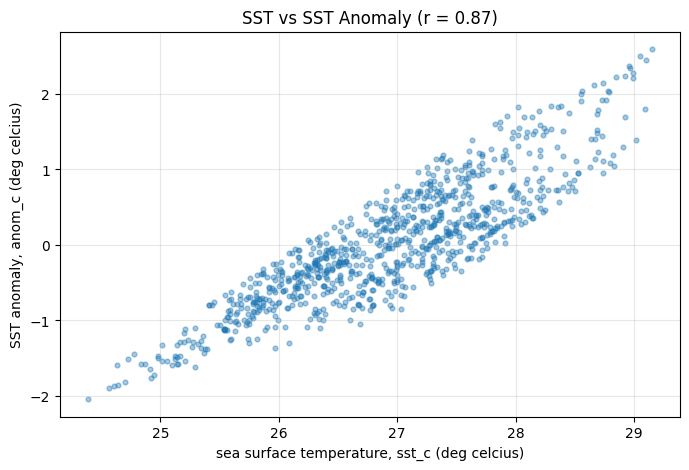

In [4]:
plt.figure(figsize=(8,5))
plt.scatter(x,y, alpha=0.4, s=12)
plt.xlabel('sea surface temperature, sst_c (deg celcius)')
plt.ylabel('SST anomaly, anom_c (deg celcius)')
plt.title(f'SST vs SST Anomaly (r = {correlation:.2f})')
plt.grid(alpha=0.3)
plt.show()

4. Explain the following

*   What the statistics tell us: Sea surface temperature is very stable, averaging about 27deg celcius with a small standard deviation, so the tropical Pacific changes only by a degree or two. The anomaly is centred near zero deg celcius, meaning most seasons are close to normal, but its range of several degrees shows strong El Nino and La Nina extremes do occur. The cumulative variable has a mean above its median, so most warm/cold spells are short, with a few long-lasting events stretching the distribution.

*   What does the correlation tell us? The correlation between sst_c and anom_c is positive and moderate to strong: when the sea surface is warmer, the anomaly tends to be higher. The relationship is not perfect because normal temperature also changes with the season,so the same SST can be a warm anomaly in one season and normal in another.


*   Does correlation mean causation? No. Correlation only shows that two variables move together. Here the anomaly is actually calculated from SST (SST minus the seasonal average), so the link comes from how the data was defined, not from one causing the other. In general, a third factor can drive both variables, so causation needs experiments or physical reasoning, not correlation alone.






5. Input to Function/model to output
Input: SST anomaly x (anom_c)
Model f
Output:ENSO phase y (oni)
y = f(x)

A simple rule-based model (NOAA thresholds):

f(x) = {El Nino x>=0.5 Neutral -0.5 < x < 0.5 La Nina x <= -0.5}

Or, as a linear model linking two numbers:\text{anom_c} = w\cdot\text{sst_c} + b

In [8]:
def f(x):
  if x >= 0.5: return 'El Nino'
  if x <= -0.5: return 'La Nina'
  return 'Neutral'

for val in [-1.2, 0.1, 1.5]:
    print(f'{val:+.1f} deg celcius: {f(val)}')

-1.2 deg celcius: La Nina
+0.1 deg celcius: Neutral
+1.5 deg celcius: El Nino
